In [18]:
import numpy as np
from scipy.interpolate import interp1d
from tqdm import tqdm
import torch
from utils import *
from genData import *
from model.unet_leaky import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(111)
torch.manual_seed(111)

# Parameters
det = 'H1L1'
f0 = 500
size = (512, 64)
Tsft = 14400
max_train_levels = [18, 19, 20, 25, 30]
seeds = range(1, 100)  # Seeds 1 to 6
num_noise_realizations = 200
version = 'H1L1_newmask_UNET_a1.0b1.0_500Hz_D20-20_T10_Tsft14400_step1_ndata5000_noise5000_latent64_th50_batch8_lr0.0001_512x64_MSELoss_dropout0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output_file = 'depth_at_pdet_0.9.npz'

# Initialize model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"./trained_model/500Hz/best_val_model_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)
model.eval()

# Function to compute detection statistic
def compute_detection_statistic(images, ref_distribution=None):
    detection_stats = np.mean(np.abs(images.transpose(0, 2, 3, 1)), axis=(1, 2, 3))
    return detection_stats

# Generate noise-only data for x_pfa
noise = np.empty((500,) + size + (4,))
for i in range(noise.shape[0]):
    noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise = normalize(noise)
noise_data = load_noise_dataset(noise)
noise_loader = make_data_loader([noise_data], batch_size=8, shuffle=False)

# Compute x_pfa
noise_predictions = []
with torch.no_grad():
    for batch in tqdm(noise_loader, desc="Processing noise for x_pfa"):
        images = batch[0].to(device)
        outputs = model(images)
        noise_predictions.append(outputs.cpu().numpy())
noise_predictions = np.concatenate(noise_predictions, axis=0)
x_pfa = np.percentile(compute_detection_statistic(noise_predictions), (1 - 0.71/100) * 100)

# Process each signal
depth_at_pdet_90 = []
for seed in seeds:
    # Load data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/skymap_{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed{seed}.npz'
    targets = np.load(filename, allow_pickle=True)['clean_image']  # Shape: (1000, 512, 64, 4)
    #targets = normalize(targets)

    for signal_idx in tqdm(range(5), desc=f"Processing signals for seed {seed}"):
        signal = targets[signal_idx*num_noise_realizations:(signal_idx+1)*num_noise_realizations]  # Shape: (1, 512, 64, 4)
        pdet_values = []

        for Sn in max_train_levels:
            # Generate 200 noise realizations
            noisy_signals = np.empty((num_noise_realizations,) + size + (4,))
            for i in range(num_noise_realizations):
                noise = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
                noisy_signals[i] = normalize(noise + signal[i])
  
            dataset = load_signal_datasetv(noisy_signals, [Sn] * num_noise_realizations)
            loader = make_data_loader([dataset], batch_size=8, shuffle=False)

            # Evaluate model
            predictions = []
            with torch.no_grad():
                for batch in loader:
                    images = batch[0].to(device)
                    outputs = model(images)
                    predictions.append(outputs.cpu().numpy())
            predictions = np.concatenate(predictions, axis=0)

            # Compute detection statistic and pdet
            detection_stats = compute_detection_statistic(predictions)
            pdet = np.sum(detection_stats > x_pfa) / detection_stats.size
            pdet_values.append(pdet)
        # Interpolate to find depth at pdet = 0.9
        pdet_values = np.array(pdet_values)
        depth = np.array(max_train_levels)
        
        interp_func = interp1d(pdet_values, depth, kind='linear', fill_value="extrapolate")
        depth_value = interp_func(0.9)
        depth_at_pdet_90.append(depth_value)

# Save results
depth_at_pdet_90 = np.array(depth_at_pdet_90)
np.savez(output_file, depth_at_pdet_90=depth_at_pdet_90)

print(f"Depths at pdet = 0.9 saved to {output_file}")
print(f"Number of valid depths: {np.sum(~np.isnan(depth_at_pdet_90))}")
print(f"Mean depth at pdet = 0.9: {np.nanmean(depth_at_pdet_90):.2f}")

Processing signals for seed 1:  80%|████████  | 4/5 [00:54<00:13, 13.57s/it]


KeyboardInterrupt: 

In [2]:
def load_signal_datasetv(images, labels):
    """
    Load the full dataset once at the beginning, including noisy and pure noise images.
    Store indices for each noise level for easy selection during training.

    Parameters:
        size (tuple): The size of the images (height, width).
        noise_levels_to_sample (list): List of noise levels to include in the dataset.
        file_paths (dict): Dictionary with paths for noisy and pure noise datasets.
        pure_noise (bool): Whether to include pure noise data in the dataset.

    Returns:
        dataset (TensorDataset): The full dataset containing all samples.
        noise_level_indices (dict): A dictionary storing indices for each noise level.
    """

    # Convert to torch tensors
    images_tensor = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    labels_tensor = torch.tensor(labels, dtype=torch.float64)
    
    full_dataset = TensorDataset(images_tensor, labels_tensor)
    
    return full_dataset


In [5]:
# Save results
depth_at_pdet_90 = np.array(depth_at_pdet_90)
np.savez(output_file, depth_at_pdet_90=depth_at_pdet_90)

print(f"Depths at pdet = 0.9 saved to {output_file}")
print(f"Number of valid depths: {np.sum(~np.isnan(depth_at_pdet_90))}")
print(f"Mean depth at pdet = 0.9: {np.nanmean(depth_at_pdet_90):.2f}")

Depths at pdet = 0.9 saved to depth_at_pdet_0.9.npz
Number of valid depths: 10
Mean depth at pdet = 0.9: 2.51


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

# Parameters
f0 = 500
size = (512, 64)
Tsft = 14400
seeds = range(1, 7)
depth_file = 'depth_at_pdet_0.9.npz'

# Load depths at pdet = 0.9
depth_data = np.load(depth_file, allow_pickle=True)
depth_at_pdet_90 = depth_data['depth_at_pdet_90']  # Shape: (6000,)

In [5]:
depth_at_pdet_90.shape

(1000,)

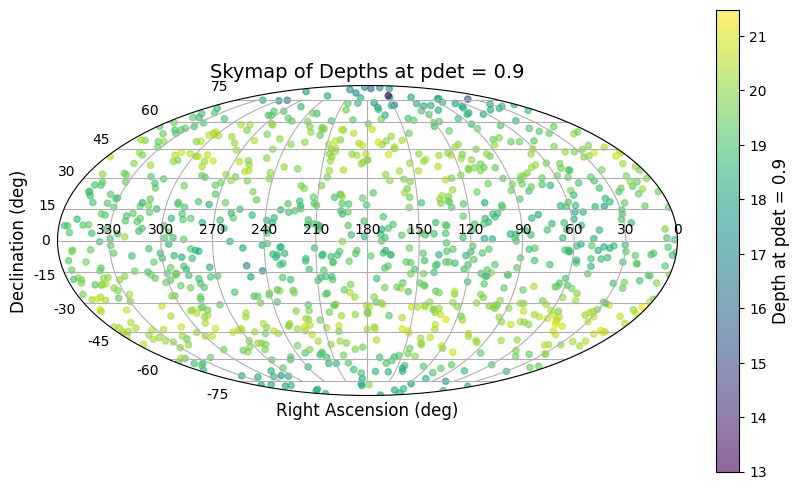

In [26]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# Parameters
f0 = 500
size = (512, 64)
Tsft = 14400
seeds = range(200)
depth_file = 'depth_at_pdet_0.9.npz'

# Load depths at pdet = 0.9
depth_data = np.load(depth_file, allow_pickle=True)
depth_at_pdet_90 = depth_data['depth_at_pdet_90']  # Shape: (6000,)

# Load RA and Dec from all seeds
alpha_deg = []
delta = []
for seed in seeds:
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/skymap_{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed{seed}.npz'
    data = np.load(filename, allow_pickle=True)
    params = data['params']
    for i in range(5):
        alpha_rad = params[i*200, -2]  # RA in radians
        alpha_deg.append(np.degrees(alpha_rad))  # Convert to degrees
        delta.append(params[i*200, -1])  # Dec in degrees

alpha_deg = np.array(alpha_deg)  # Shape: (6000,)
delta = np.array(delta)  # Shape: (6000,)

# Filter out invalid depths
valid_mask = ~np.isnan(depth_at_pdet_90)
ra_plot_rad = np.radians(180 - alpha_deg[valid_mask])  # RA in degrees -> radians, mirrored for astronomical convention
dec_plot_rad = delta[valid_mask]  # Dec in degrees -> radians
depths_valid = depth_at_pdet_90[valid_mask]

# Create the skymap
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter plot with depths as color
scatter = ax.scatter(ra_plot_rad, dec_plot_rad, c=depths_valid, s=20, alpha=0.6, cmap='viridis', 
                    vmin=np.min(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]), 
                    vmax=np.max(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]))

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Depth at pdet = 0.9', orientation='vertical')
cbar.set_label('Depth at pdet = 0.9', fontsize=12)

# Customize the plot
ax.set_xlabel('Right Ascension (deg)', fontsize=12)
ax.set_ylabel('Declination (deg)', fontsize=12)
ax.grid(True)

# Set RA ticks (in degrees, reversed for astronomical convention)
ra_ticks_deg = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210, 180])
ra_ticks_rad = np.radians(180 - ra_ticks_deg)
ax.set_xticks(ra_ticks_rad)
ax.set_xticklabels([f'{t:.0f}' for t in ra_ticks_deg])

# Set Dec ticks
dec_ticks_deg = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75])
dec_ticks_rad = np.radians(dec_ticks_deg)
ax.set_yticks(dec_ticks_rad)
ax.set_yticklabels([f'{t:.0f}' for t in dec_ticks_deg])

# Title
plt.title('Skymap of Depths at pdet = 0.9', fontsize=14)

# Save and show
plt.savefig('skymap_depth.png')
plt.show()